In [1]:
from pathlib import Path
from string import ascii_lowercase, ascii_uppercase

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from scipy.stats import false_discovery_control, t

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


In [2]:
# ------------------------------------------------------------
# 1) Helpers
# ------------------------------------------------------------


def add_time_coords(ds, winter_start_month=8):
    """
    Add month and winter_year coordinates.
    winter_year=2025 means Oct 2024 ... Mar 2025 if winter_start_month=10.
    """
    wy = xr.where(
        ds.time.dt.month >= winter_start_month,
        ds.time.dt.year + 1,
        ds.time.dt.year,
    )

    return ds.assign_coords(
        month=("time", ds.time.dt.month.data),
        winter_year=("time", wy.data),
    )


def compute_monthly_anomalies(ds, clim_start="2006-01-01", clim_end="2020-12-31"):
    """
    Put all variables onto a common monthly grid and compute month-of-year anomalies.
    
    ds_m = xr.Dataset()

    for v in list(ds.data_vars):
        if v == 'h2o':         
            ds_m[v] = ds[v].resample(time="MS").mean()
        else:
            ds_m[v] = ds[v].copy()    
            
    #ds_m = ds.copy()
    """
    ds_m = add_time_coords(ds)

    clim = (
        ds_m.sel(time=slice(clim_start, clim_end))
        .groupby("time.month")
        .mean("time", skipna=True)
    )

    anom = ds_m.groupby("time.month") - clim
    anom = add_time_coords(anom)#.chunk({"time":-1}).interpolate_na(dim = 'time')
    return anom, clim


def empirical_two_sided_p(ref, obs, center_zero=True):
    """
    Empirical two-sided p-value for one target observation vs a historical sample.
    ref : 1D array of historical anomalies for the same calendar month
    obs : scalar target anomaly
    """
    ref = np.asarray(ref, dtype=float)
    ref = ref[np.isfinite(ref)]

    if ref.size < 5 or not np.isfinite(obs):
        return np.nan

    center = 0.0 if center_zero else np.nanmedian(ref)
    return (1 + np.sum(np.abs(ref - center) >= np.abs(obs - center))) / (ref.size + 1)


# ------------------------------------------------------------
# 2) Local p-values for one target winter
# ------------------------------------------------------------


def pvals_vs_reference_monthly(
    anom,
    target_winter,
    months=(8, 9,10, 11, 12, 1, 2, 3),
    ref_winters=None,
    center_zero=True,
):
    """
    Compute local empirical p-values for each target month/level/pixel.

    Parameters
    ----------
    anom : xr.Dataset
        Monthly anomalies with coords month and winter_year.
    target_winter : int
        E.g. 2025 means Oct 2024 - Mar 2025.
    months : tuple
        Months to include in the winter analysis.
    ref_winters : array-like or None
        Which winter_year values define the null distribution.
        If None, use all winters except target_winter.
    center_zero : bool
        If True, compare against 0-centered anomalies.
        If False, compare against the historical median for each month.
    """
    anom = add_time_coords(anom)
    anom = anom.where(anom.time.dt.month.isin(months), drop=True)

    all_winters = np.asarray(np.unique(anom["winter_year"].values))
    if ref_winters is None:
        ref_winters = all_winters[all_winters != target_winter]

    target = anom.where(anom.winter_year == target_winter, drop=True)

    out = []
    for ts in target.time.values:
        obs = target.sel(time=ts)
        month = int(obs.time.dt.month.item())

        ref = anom.where(
            (anom.time.dt.month == month) & anom.winter_year.isin(ref_winters),
            drop=True,
        )

        # apply_ufunc works variable-by-variable across all non-time dims
        p = xr.apply_ufunc(
            empirical_two_sided_p,
            ref,
            obs,
            input_core_dims=[["time"], []],
            output_core_dims=[[]],
            kwargs={"center_zero": center_zero},
            vectorize=True,
            dask="parallelized",
            output_dtypes=[float],
        )

        out.append(p.expand_dims(time=[ts]))

    return xr.concat(out, dim="time")


# ------------------------------------------------------------
# 3) Field significance via FDR
# ------------------------------------------------------------


def fdr_adjust_dataset(p_ds, alpha=0.1, method="bh"):
    """
    FDR-adjust each data variable over all of its cells (e.g. time x plev).
    Returns adjusted q-values and a boolean significance mask.
    """
    q_ds = xr.Dataset()
    sig_ds = xr.Dataset()

    for name, da in p_ds.data_vars.items():
        flat = da.stack(test=da.dims)

        q_flat = xr.apply_ufunc(
            false_discovery_control,
            flat,
            input_core_dims=[["test"]],
            output_core_dims=[["test"]],
            kwargs={"method": method},
            vectorize=False,
            dask="parallelized",
            output_dtypes=[float],
        )

        q = q_flat.unstack("test")
        q_ds[name] = q
        sig_ds[name] = q < alpha

    return q_ds, sig_ds


# ------------------------------------------------------------
# 4) Optional parametric alternative
# ------------------------------------------------------------


def predictive_t_pvals(
    anom,
    target_winter,
    months=(10, 11, 12, 1, 2, 3),
    ref_winters=None,
):
    """
    Parametric p-values for one new observation vs historical sample.
    t = (x* - mean_ref) / (sd_ref * sqrt(1 + 1/n))
    """
    anom = add_time_coords(anom)
    anom = anom.where(anom.time.dt.month.isin(months), drop=True)

    all_winters = np.asarray(np.unique(anom["winter_year"].values))
    if ref_winters is None:
        ref_winters = all_winters[all_winters != target_winter]

    target = anom.where(anom.winter_year == target_winter, drop=True)

    out = []
    for ts in target.time.values:
        obs = target.sel(time=ts)
        month = int(obs.time.dt.month.item())

        ref = anom.where(
            (anom.time.dt.month == month) & anom.winter_year.isin(ref_winters),
            drop=True,
        )

        mu = ref.mean("time", skipna=True)
        sd = ref.std("time", ddof=1, skipna=True)
        n = ref.count("time")

        tstat = (obs - mu) / (sd * np.sqrt(1 + 1 / n))

        p = xr.apply_ufunc(
            lambda tt, df: 2.0 * t.sf(np.abs(tt), df),
            tstat,
            n - 1,
            vectorize=True,
            dask="parallelized",
            output_dtypes=[float],
        )

        out.append(p.expand_dims(time=[ts]))

    return xr.concat(out, dim="time")


def mc_local_pvals(
    anom,
    target_winter=2025,
    months=(10, 11, 12, 1, 2, 3),
    var_names=("h2o", "o3", "temperature"),
    B=10000,
    rng=None,
):
    """
    Monte Carlo local p-values for each target month-pressure bin.
    Uses same-calendar-month reference distribution across non-target winters.
    """
    rng = np.random.default_rng(rng)
    anom = anom.where(anom.time.dt.month.isin(months), drop=True)

    ref = anom.where(anom.winter_year != target_winter, drop=True)
    obs = anom.where(anom.winter_year == target_winter, drop=True)

    out = xr.Dataset()

    for v in var_names:
        p_slices = []

        for ts in obs.time.values:
            x = obs[v].sel(time=ts)
            m = int(x.time.dt.month.item())

            ref_m = ref[v].where(ref.month == m, drop=True)  # dims: time, ...

            # Monte Carlo null: draw one historical sample index repeatedly
            n_ref = ref_m.sizes["time"]
            idx = rng.integers(0, n_ref, size=B)

            null = ref_m.isel(time=xr.DataArray(idx, dims="draw"))  # draw, ...
            # two-sided exceedance
            extreme = np.abs(null) >= np.abs(x)
            p = (extreme.sum("draw") + 1) / (B + 1)

            p_slices.append(p.expand_dims(time=[ts]))

        out[v] = xr.concat(p_slices, dim="time")

    return out

def anomalize(ds, how = 'dayofyear'):
    clim = ds.sel(time = slice('2006','2020')).groupby(f'time.{how}').mean()
    anom = (ds.groupby(f'time.{how}')-clim).load()
    return anom, clim


In [3]:
rootpath = Path("/sto0/data/Intermediate/Hunga_Tonga_byAles/")
inpath = rootpath / "data"
xr.set_options(keep_attrs=True)
plt.rcParams.update({"font.size": 22})

In [4]:
infiles = sorted((rootpath / "stocker" / "MLSv6" / "Update_202604").glob("*.nc"))
mls_suffix = "v6"

In [5]:
ds = xr.open_mfdataset(infiles, parallel=True, combine="nested")
ds["O3"].attrs["units"] = "ppmv"
ds["h2o"].attrs["units"] = "ppmv"
ds["temperature"].attrs["units"] = "K"
ds

<xarray.Dataset> Size: 376MB
Dimensions:        (latitude_bins: 72, time: 7914, pressure: 55)
Coordinates:
  * latitude_bins  (latitude_bins) float64 576B -88.75 -86.25 ... 86.25 88.75
  * time           (time) datetime64[ns] 63kB 2004-08-02 ... 2026-04-02
  * pressure       (pressure) float32 220B 1e+03 825.4 681.3 ... 2.154e-05 1e-05
Data variables:
    h2o            (latitude_bins, time, pressure) float32 125MB dask.array<chunksize=(72, 7914, 55), meta=np.ndarray>
    O3             (latitude_bins, time, pressure) float32 125MB dask.array<chunksize=(72, 7914, 55), meta=np.ndarray>
    temperature    (latitude_bins, time, pressure) float32 125MB dask.array<chunksize=(72, 7914, 55), meta=np.ndarray>
Attributes:
    title:    Aura MLS v6.01 Level-2 data product
    history:  Postprocessed by WEGC; screened using MLS precision estimates a...

In [6]:
weights = np.cos(np.deg2rad(ds.latitude_bins))
weights.name = "weights"

In [7]:
pres_start = 200
pres_end = 0.01
ds_sel = (
    ds.sel(
        latitude_bins=slice(60, None),
        # time = slice(f'{s_year}-{s_month-1:02d}', time_end),
        pressure=slice(pres_start, pres_end),
    )
    .weighted(weights)
    .mean("latitude_bins")
    #.interpolate_na(dim="time")
)  # .load()
ds_sel

<xarray.Dataset> Size: 7MB
Dimensions:      (pressure: 37, time: 7914)
Coordinates:
  * pressure     (pressure) float32 148B 177.8 146.8 121.2 ... 0.02154 0.01
  * time         (time) datetime64[ns] 63kB 2004-08-02 2004-08-03 ... 2026-04-02
Data variables:
    h2o          (time, pressure) float64 2MB dask.array<chunksize=(7914, 37), meta=np.ndarray>
    O3           (time, pressure) float64 2MB dask.array<chunksize=(7914, 37), meta=np.ndarray>
    temperature  (time, pressure) float64 2MB dask.array<chunksize=(7914, 37), meta=np.ndarray>
Attributes:
    title:    Aura MLS v6.01 Level-2 data product
    history:  Postprocessed by WEGC; screened using MLS precision estimates a...

In [9]:
"""
anom, clim = compute_monthly_anomalies(
    ds[['O3','temperature']],
    clim_start="2006-01-01",
    clim_end="2020-12-31",
)
anom_h2o, clim_h2o = compute_monthly_anomalies(
    ds[['h2o']],
    clim_start="2006-01-01",
    clim_end="2020-12-31",
)
""" 

In [8]:
anom_mon, clim_mon = anomalize(ds_sel, how = 'month')
clim_mon_new = clim_mon.copy()
clim_mon_new = clim_mon_new.rename({'month': 'dayofyear'})
# https://chatgpt.com/share/68e516e4-8478-8006-8baf-dfdd98ef98fe
clim_mon_new['dayofyear'] = [16, 45, 74, 105, 135, 166, 196, 227, 258, 289, 319, 350]
clim_mon_new = clim_mon_new.interp(dayofyear = np.arange(1,367), kwargs={"fill_value": "extrapolate"})
anom_int = add_time_coords(ds_sel.groupby(f'time.dayofyear')-clim_mon_new).drop_vars('dayofyear')#.load()

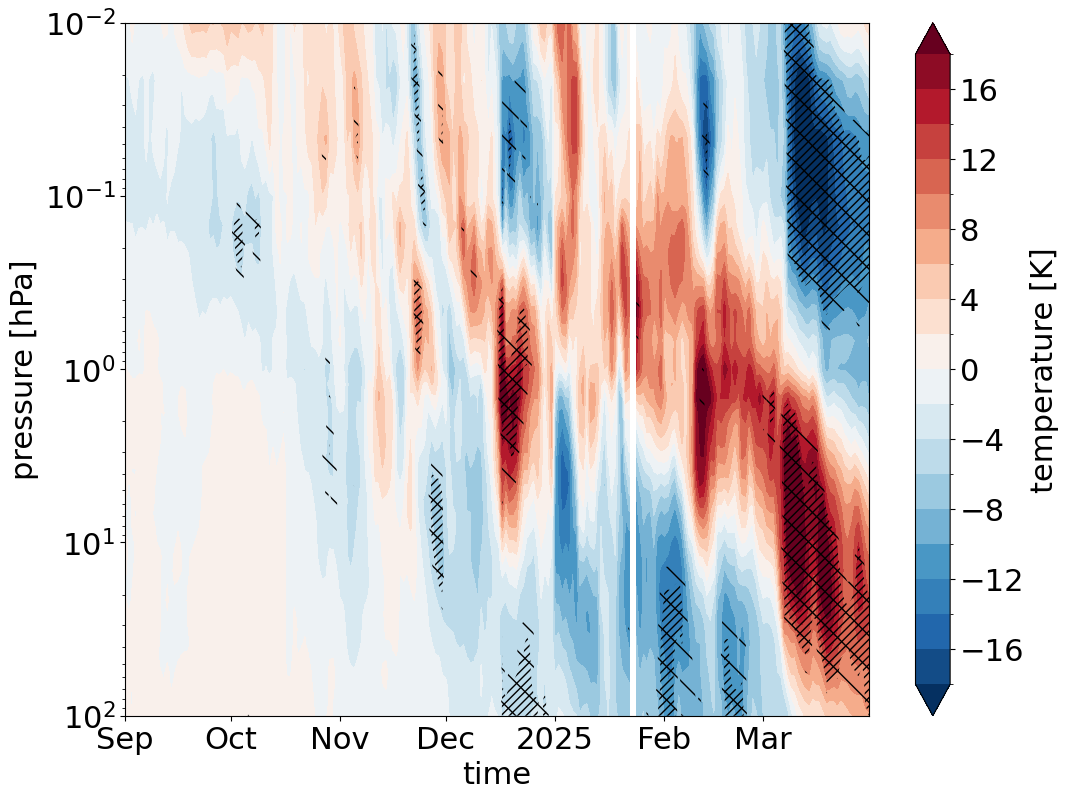

In [372]:
temp2 = anom_int.sel(
    #latitude_bins = slice(60,None),
    time = slice(f'{s_year}-{s_month-1:02d}', time_end),
    pressure = slice(pres_start,pres_end),    
)#.weighted(weights).mean('latitude_bins')
#temp2 = temp2.interpolate_na(dim = 'time')
p = temp2['temperature'].sel(
    pressure = slice(100,0.01)
).plot.contourf(
    x = 'time', yincrease = False, center=0, 
    robust = True, levels = 21, cmap = 'RdBu_r', 
    size = 9
)
ax = p.axes


p_local_int['temperature'].sel(pressure = slice(100,0.01)).plot.contourf(
    x = 'time', ax = ax, yincrease = False, 
    levels=[0, 0.05],
    hatches=["////", None],
    colors="none",
    add_colorbar=False,    
)

p_local_int['temperature'].sel(pressure = slice(100,0.01)).plot.contourf(
    x = 'time', ax = ax, yincrease = False, 
    levels=[0, 0.1],
    hatches=["\\", None],
    colors="none",
    add_colorbar=False,    
)

plt.yscale('log')

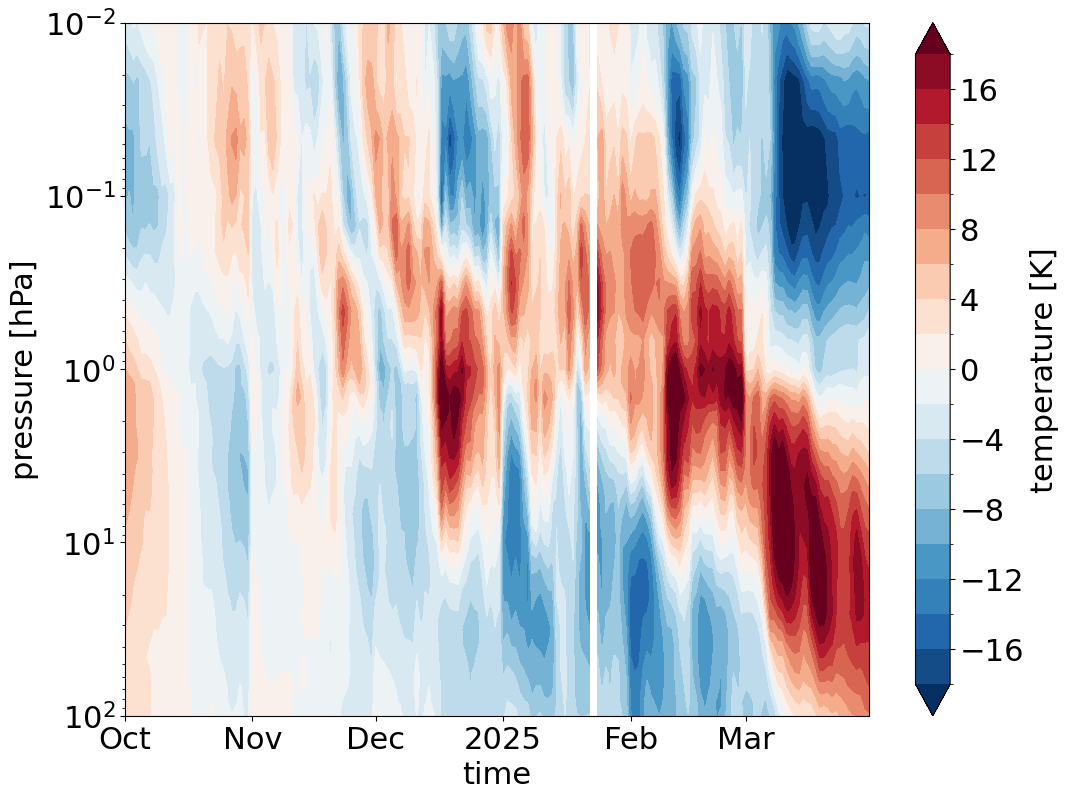

In [301]:
temp2 = anom.sel(
    latitude_bins = slice(60,None),
    time = slice(f'{s_year}-{s_month:02d}', time_end),
    pressure = slice(pres_start,pres_end),    
).weighted(weights).mean('latitude_bins')
#temp2 = temp2.interpolate_na(dim = 'time')
temp2['temperature'].sel(pressure = slice(100,0.01)).plot.contourf(x = 'time', yincrease = False, center =0, robust = True, levels = 21, cmap = 'RdBu_r', size = 9)
plt.yscale('log')

In [9]:
anom_int_to3 = (
    anom_int[["temperature", "O3"]].chunk({"time": -1})#.interpolate_na("time")
)
p_local_int = pvals_vs_reference_monthly(
    anom_int_to3,
    target_winter=2025,  # Oct 2024 - Mar 2025
    ref_winters=None,
    center_zero=True,
).load()
p_local_int

<xarray.Dataset> Size: 146kB
Dimensions:      (time: 243, pressure: 37)
Coordinates:
  * time         (time) datetime64[ns] 2kB 2024-08-01 2024-08-02 ... 2025-03-31
  * pressure     (pressure) float32 148B 177.8 146.8 121.2 ... 0.02154 0.01
Data variables:
    temperature  (time, pressure) float64 72kB 0.07704 0.05085 ... 0.3819 0.5769
    O3           (time, pressure) float64 72kB 0.003082 0.004622 ... 0.5277 nan
Attributes:
    title:    Aura MLS v6.01 Level-2 data product
    history:  Postprocessed by WEGC; screened using MLS precision estimates a...

In [12]:
anom_int_to3.resample(time = '1M').mean()

<xarray.Dataset> Size: 157kB
Dimensions:      (time: 261, pressure: 37)
Coordinates:
  * time         (time) datetime64[ns] 2kB 2004-08-31 2004-09-30 ... 2026-04-30
  * pressure     (pressure) float32 148B 177.8 146.8 121.2 ... 0.02154 0.01
Data variables:
    temperature  (time, pressure) float64 77kB dask.array<chunksize=(261, 37), meta=np.ndarray>
    O3           (time, pressure) float64 77kB dask.array<chunksize=(261, 37), meta=np.ndarray>
Attributes:
    title:    Aura MLS v6.01 Level-2 data product
    history:  Postprocessed by WEGC; screened using MLS precision estimates a...

In [18]:
xr.merge([anom_int_to3.resample(time = '1M').mean(), anom_int_h2o]).to_netcdf('pcap_anom_MLS.nc')

In [13]:
anom_int_h2o

<xarray.Dataset> Size: 79kB
Dimensions:   (pressure: 37, time: 261)
Coordinates:
  * pressure  (pressure) float32 148B 177.8 146.8 121.2 ... 0.04642 0.02154 0.01
  * time      (time) datetime64[ns] 2kB 2004-08-31 2004-09-30 ... 2026-04-30
Data variables:
    h2o       (time, pressure) float64 77kB dask.array<chunksize=(261, 37), meta=np.ndarray>
Attributes:
    title:    Aura MLS v6.01 Level-2 data product
    history:  Postprocessed by WEGC; screened using MLS precision estimates a...

In [10]:
anom_int_h2o = anom_int[['h2o']].chunk({'time':-1}).resample(time = '1M').mean().interpolate_na('time')
p_local_int_h2o = pvals_vs_reference_monthly(
    anom_int_h2o,
    target_winter=2025,  # Oct 2024 - Mar 2025
    ref_winters=None,
    center_zero=True,
).load()
p_local_int_h2o

<xarray.Dataset> Size: 3kB
Dimensions:   (time: 8, pressure: 37)
Coordinates:
  * time      (time) datetime64[ns] 64B 2024-08-31 2024-09-30 ... 2025-03-31
  * pressure  (pressure) float32 148B 177.8 146.8 121.2 ... 0.04642 0.02154 0.01
Data variables:
    h2o       (time, pressure) float64 2kB 0.6364 0.5909 ... 0.9545 0.3182
Attributes:
    title:    Aura MLS v6.01 Level-2 data product
    history:  Postprocessed by WEGC; screened using MLS precision estimates a...

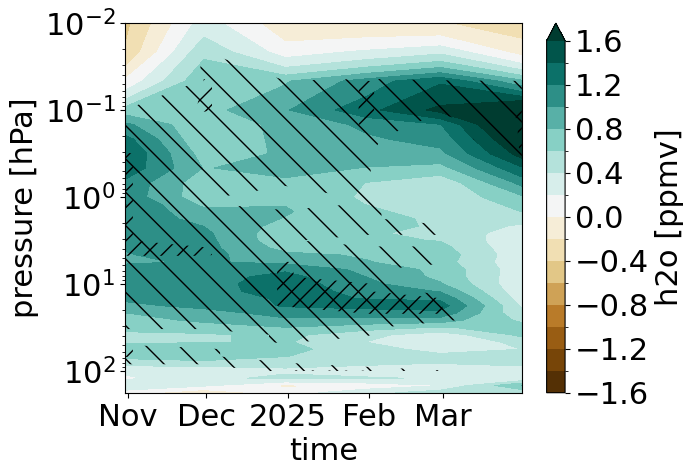

In [386]:
p = anom_int_h2o['h2o'].sel(
    time = slice(f'{s_year}-{s_month:02d}', time_end),   
).plot.contourf(x = 'time', yincrease = False, center =0, robust = True, levels = 21, cmap = 'BrBG')
ax = p.axes
p_local_int_h2o['h2o'].sel(pressure = slice(100,0.01)).plot.contourf(
    x = 'time', ax = ax, yincrease = False, 
    levels=[0, 0.05],
    hatches=["//", None],
    colors="none",
    add_colorbar=False,    
)

p_local_int_h2o['h2o'].sel(pressure = slice(100,0.01)).plot.contourf(
    x = 'time', ax = ax, yincrease = False, 
    levels=[0, 0.1],
    hatches=["\\", None],
    colors="none",
    add_colorbar=False,    
)
plt.yscale('log')

In [288]:
# Option A: null = all other winters
p_local = pvals_vs_reference_monthly(
    anom[["O3", "temperature"]].chunk({"time": -1}),
    target_winter=2025,  # Oct 2024 - Mar 2025
    ref_winters=None,
    center_zero=True,
).compute()

p_local_h2o = pvals_vs_reference_monthly(
    anom_h2o.chunk({"time": -1}),
    target_winter=2025,  # Oct 2024 - Mar 2025
    ref_winters=None,
    center_zero=True,
).compute()

In [268]:
p_local_mc = mc_local_pvals(anom.load(), B=1000, var_names=('O3', 'temperature'))
p_local_mc

<xarray.Dataset> Size: 109kB
Dimensions:      (time: 182, pressure: 37)
Coordinates:
  * time         (time) datetime64[ns] 1kB 2024-10-01 2024-10-02 ... 2025-03-31
  * pressure     (pressure) float32 148B 177.8 146.8 121.2 ... 0.02154 0.01
Data variables:
    O3           (time, pressure) float64 54kB 0.04595 0.2498 ... 0.000999
    temperature  (time, pressure) float64 54kB 0.03297 0.00999 ... 0.4615

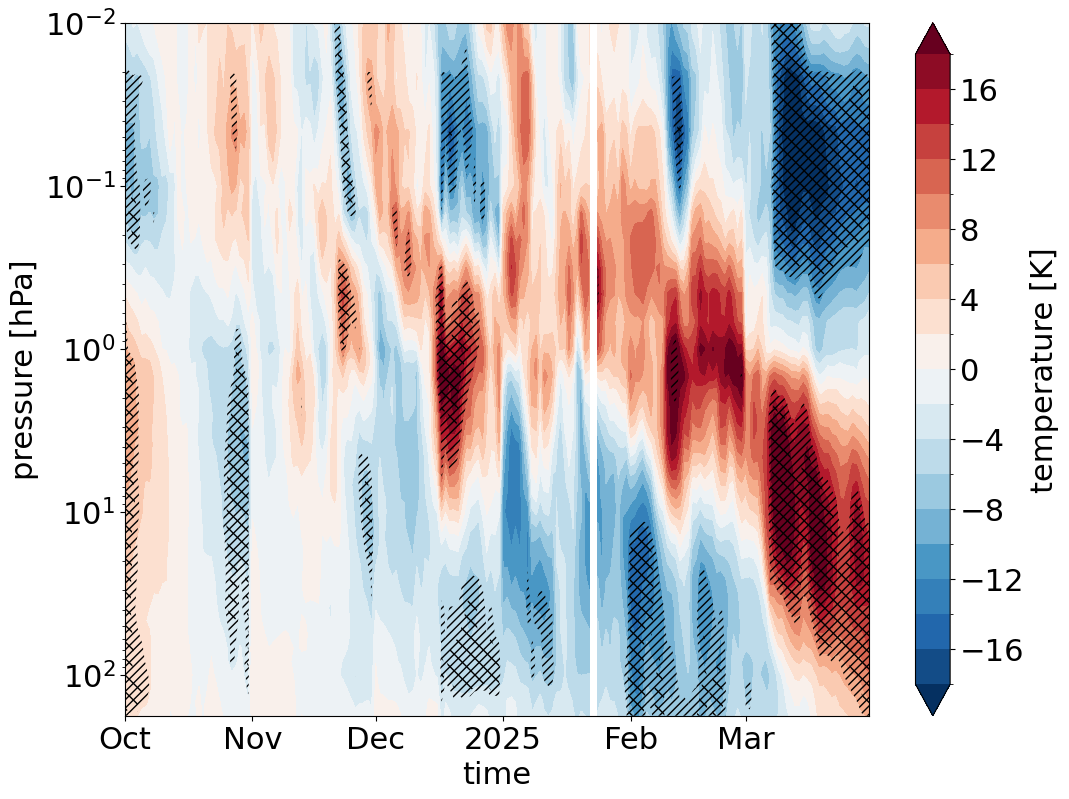

In [289]:
s_year = 2024
e_year = 2025
s_month = 10
e_month = 3
time_start = f"{s_year}-{s_month:02d}"
time_end = f"{e_year}-{e_month:02d}"
cmap = "RdBu_r"

sel_var = "temperature"
temp = anom[sel_var].sel(
    time=slice(time_start, time_end),
)
p = temp.plot.contourf(
    x="time",
    robust=True,
    cmap=cmap,
    yincrease=False,
    extend="both",
    levels=np.arange(-18, 20, 2),  # 21,
    center=0,
    size = 9,
    # ax = ax
)

ax = p.axes
# anom['temperature'].plot(x = 'time', yincrease = False, vmax = 0.1)
p_local[sel_var].plot.contourf(
    x="time",
    yincrease=False,
    levels=[0, 0.05],
    hatches=["\\\\", None],
    colors="none",
    ax=ax,
    add_colorbar=False,
)

p_local[sel_var].plot.contourf(
    x="time",
    yincrease=False,
    levels=[0, 0.1],
    hatches=["////", None],
    colors="none",
    ax=ax,
    add_colorbar=False,
)


"""q_fdr, sig = fdr_adjust_dataset(p_local[[sel_var]], alpha=0.1, method="bh")
q_fdr["temperature"].plot.contour(
    x="time", yincrease=False, levels=[0, 0.3], colors="k", ax=ax, add_colorbar=False
)"""
plt.yscale("log")

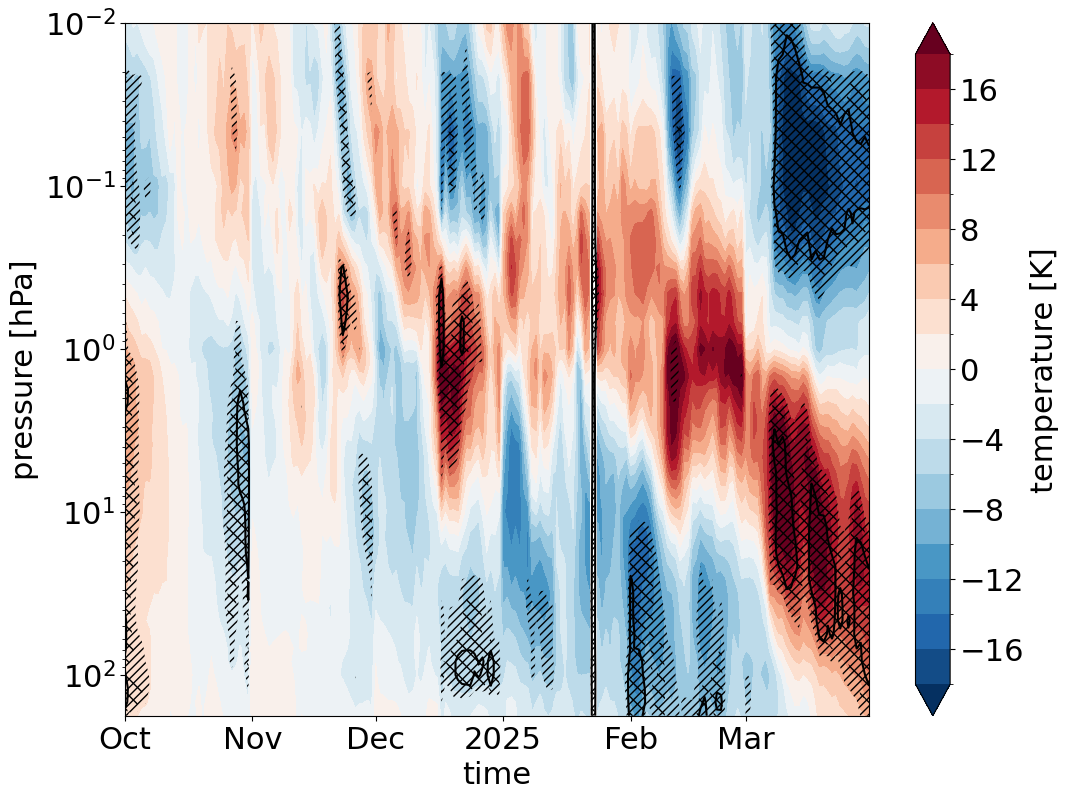

In [271]:
s_year = 2024
e_year = 2025
s_month = 10
e_month = 3
time_start = f"{s_year}-{s_month:02d}"
time_end = f"{e_year}-{e_month:02d}"
cmap = "RdBu_r"

sel_var = "temperature"
temp = anom[sel_var].sel(
    time=slice(time_start, time_end),
)
p = temp.plot.contourf(
    x="time",
    robust=True,
    cmap=cmap,
    yincrease=False,
    extend="both",
    levels=np.arange(-18, 20, 2),  # 21,
    center=0,
    size = 9
    # ax = ax
)

ax = p.axes
# anom['temperature'].plot(x = 'time', yincrease = False, vmax = 0.1)
p_local_mc[sel_var].plot.contourf(
    x="time",
    yincrease=False,
    levels=[0, 0.05],
    hatches=["\\\\", None],
    colors="none",
    ax=ax,
    add_colorbar=False,
)

p_local_mc[sel_var].plot.contourf(
    x="time",
    yincrease=False,
    levels=[0, 0.1],
    hatches=["////", None],
    colors="none",
    ax=ax,
    add_colorbar=False,
)


q_fdr, sig = fdr_adjust_dataset(p_local_mc[[sel_var]], alpha=0.1, method="bh")
q_fdr["temperature"].plot.contour(
    x="time", yincrease=False, levels=[0, 0.3], colors="k", ax=ax, add_colorbar=False
)
plt.yscale("log")

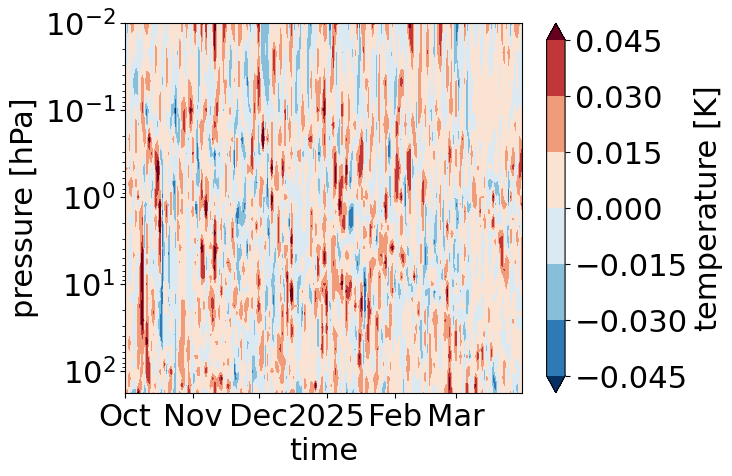

In [161]:
diff = p_local_mc[sel_var]-p_local[sel_var]
diff.plot.contourf(x = 'time', yincrease = False, robust = True)
plt.yscale('log')

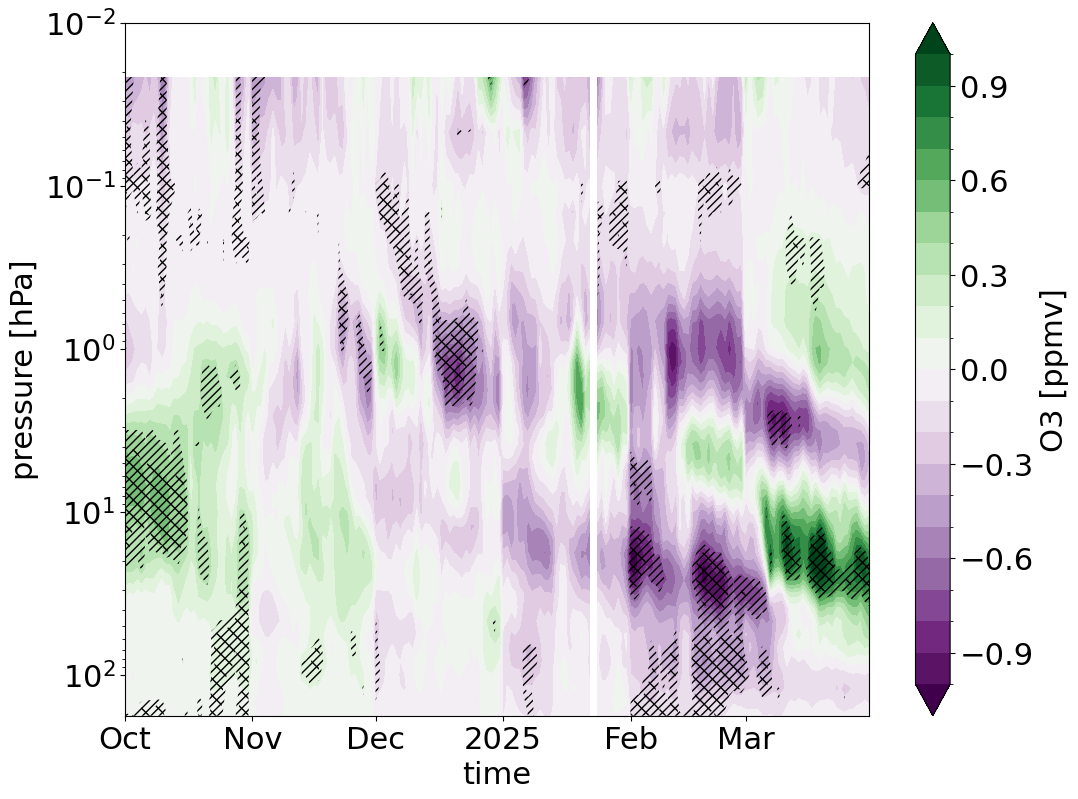

In [272]:
s_year = 2024
e_year = 2025
s_month = 10
e_month = 3
time_start = f"{s_year}-{s_month:02d}"
time_end = f"{e_year}-{e_month:02d}"
cmap = "PRGn"

sel_var = "O3"
temp = anom[sel_var].sel(time=slice(time_start, time_end))
p = temp.plot.contourf(
    x="time",
    robust=True,
    cmap=cmap,
    yincrease=False,
    extend="both",
    levels=np.arange(-1, 1.1, 0.1),  # 21,
    center=0,
    size = 9,
    # ax = ax
)

ax = p.axes
# anom['temperature'].plot(x = 'time', yincrease = False, vmax = 0.1)
p_local[sel_var].sel(time=slice(time_start, time_end)).plot.contourf(
    x="time",
    yincrease=False,
    levels=[0, 0.05],
    hatches=["\\\\", None],
    colors="none",
    ax=ax,
    add_colorbar=False,
)

p_local[sel_var].sel(time=slice(time_start, time_end)).plot.contourf(
    x="time",
    yincrease=False,
    levels=[0, 0.1],
    hatches=["////", None],
    colors="none",
    ax=ax,
    add_colorbar=False,
)

"""q_fdr, sig = fdr_adjust_dataset(
    p_local[[sel_var]].sel(
        pressure = slice(None,0.02)
    ), 
    alpha=0.1, method="bh")
q_fdr[sel_var].plot.contour(
    x="time", yincrease=False, levels=[0, 0.3], colors="k", ax=ax, add_colorbar=False
)"""

plt.yscale("log")

## 2023-2024

In [70]:
anom_int_to3 = (
    anom_int[["temperature", "O3"]].chunk({"time": -1})#.interpolate_na("time")
)
p_local_int = pvals_vs_reference_monthly(
    anom_int_to3,
    target_winter=2024,  # Oct 2024 - Mar 2025
    ref_winters=None,
    center_zero=True,
).load()
p_local_int

<xarray.Dataset> Size: 147kB
Dimensions:      (time: 244, pressure: 37)
Coordinates:
  * time         (time) datetime64[ns] 2kB 2023-08-01 2023-08-02 ... 2024-03-31
  * pressure     (pressure) float32 148B 177.8 146.8 121.2 ... 0.02154 0.01
Data variables:
    temperature  (time, pressure) float64 72kB 0.2157 0.359 ... 0.4507 0.3255
    O3           (time, pressure) float64 72kB 0.8444 0.9445 ... 0.5164 nan
Attributes:
    title:    Aura MLS v6.01 Level-2 data product
    history:  Postprocessed by WEGC; screened using MLS precision estimates a...

In [71]:
anom_int_h2o = anom_int[['h2o']].chunk({'time':-1}).resample(time = '1M').mean().interpolate_na('time')
p_local_int_h2o = pvals_vs_reference_monthly(
    anom_int_h2o,
    target_winter=2024,  # Oct 2024 - Mar 2025
    ref_winters=None,
    center_zero=True,
).load()
p_local_int_h2o

<xarray.Dataset> Size: 3kB
Dimensions:   (time: 8, pressure: 37)
Coordinates:
  * time      (time) datetime64[ns] 64B 2023-08-31 2023-09-30 ... 2024-03-31
  * pressure  (pressure) float32 148B 177.8 146.8 121.2 ... 0.04642 0.02154 0.01
Data variables:
    h2o       (time, pressure) float64 2kB 0.6818 0.09091 0.3636 ... 0.4545 0.5
Attributes:
    title:    Aura MLS v6.01 Level-2 data product
    history:  Postprocessed by WEGC; screened using MLS precision estimates a...

h2o 1.7999999999999992
O3 0.6999999999999997
temperature 10.0
TE+WV+O3_time-evolution_2023-09-2024-03_MLSv6_anom-int_significance.pdf


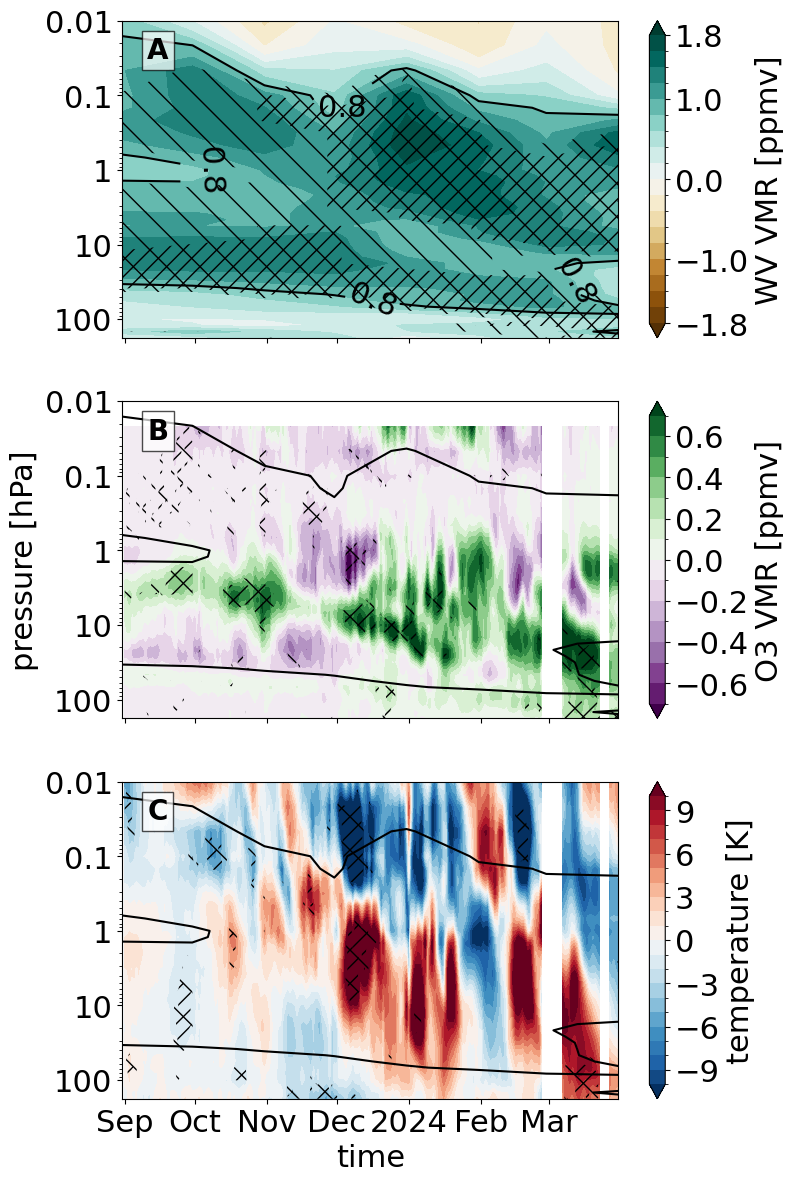

In [72]:
n_rows = 3
f, axes = plt.subplots(n_rows, 1, figsize=(8, 14), sharex =True)
weights = np.cos(np.deg2rad(ds.latitude_bins))
weights.name = "weights"
pres_start=200
pres_end = 0.01
s_year = 2023
e_year = 2024
s_month = 9
e_month = 3
time_start = f'{s_year}-{s_month:02d}'
time_end =  f'{e_year}-{e_month:02d}'
t_cmax = 10
t_cmax_step = 1

sel_var_ls = ['h2o','O3','temperature',]
cmap_ls = ['BrBG',"PRGn",'RdBu_r',]
long_name_ls = ['WV VMR', 'O3 VMR', 'temperature']


temp_dict = {}
for i, (sel_var, ax, cmap, long_name) in enumerate(zip(sel_var_ls,axes,cmap_ls, long_name_ls)):
   
    if sel_var == 'h2o':
        temp = anom_int_h2o[sel_var].sel(
            #latitude_bins = slice(60,None),
            time = slice(f'{s_year}-{s_month-1:02d}', time_end),
            pressure = slice(pres_start,pres_end),    
        )#.weighted(weights).mean('latitude_bins')
        temp = temp.interpolate_na(dim = 'time')
    else:
        temp = anom_int_to3[sel_var].sel(
            #latitude_bins = slice(60,None),
            time = slice(time_start, time_end),
            pressure = slice(pres_start,pres_end),    
        )#.weighted(weights).mean('latitude_bins')

    temp.attrs['long_name'] = long_name
    temp_dict[sel_var] = temp

    if sel_var == 'O3':
        p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = np.arange(-.7,.8,0.1),
            ax = ax, 
        )
        p_local_int[sel_var].sel(
            time = slice(time_start, time_end),
        ).plot.contourf(
            x = 'time', ax = ax, yincrease = False, 
            levels=[0, 0.05],
            hatches=["//", None],
            colors="none",
            add_colorbar=False,    
        )
        p_local_int[sel_var].sel(
            time = slice(time_start, time_end),
        ).plot.contourf(
            x = 'time', ax = ax, yincrease = False, 
            levels=[0, 0.1],
            hatches=["\\", None],
            colors="none",
            add_colorbar=False, 
        )
    elif sel_var == 'h2o':
        p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = np.arange(-1.8,2,0.2),
            ax = ax, cbar_kwargs = dict(ticks = [-1.8,-1,0,1,1.8])
        )
        p_local_int_h2o[sel_var].plot.contourf(
            x = 'time', ax = ax, yincrease = False, 
            levels=[0, 0.05],
            hatches=["//", None],
            colors="none",
            add_colorbar=False,    
        )
        p_local_int_h2o[sel_var].plot.contourf(
            x = 'time', ax = ax, yincrease = False, 
            levels=[0, 0.1],
            hatches=["\\", None],
            colors="none",
            add_colorbar=False,    
        )

        
    else:
        p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = np.arange(-t_cmax,t_cmax+t_cmax_step,t_cmax_step),#21,
            center = 0,
            ax = ax
        )
        p_local_int[sel_var].sel(
            time = slice(time_start, time_end),
        ).plot.contourf(
            x = 'time', ax = ax, yincrease = False, 
            levels=[0, 0.05],
            hatches=["//", None],
            colors="none",
            add_colorbar=False,    
        )
        p_local_int[sel_var].sel(
            time = slice(time_start, time_end),
        ).plot.contourf(
            x = 'time', ax = ax, yincrease = False, 
            levels=[0, 0.1],
            hatches=["\\", None],
            colors="none",
            add_colorbar=False, 
        )

        
    print(sel_var, p.colorbar.vmax)
    if sel_var in ['h2o','temperature','O3']:
        CS = temp_dict['h2o'].plot.contour(
            x = 'time', 
            yincrease = False, add_colorbar = False, 
            levels = [0.8],
            colors = ('k'),
            ax = ax
        )
    if sel_var in ['h2o']:
        ax.clabel(CS)
    
    ax.set_yscale('log')
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)
    
    if i != n_rows-1:
        ax.set_xlabel('')

    if i != 1:
        ax.set_ylabel('')

    label = ascii_uppercase[i]
    ax.text(
            0.05,
            0.95,
            label,
            transform=ax.transAxes,
            fontsize=20,
            fontweight="bold",
            va="top",
            bbox={"alpha": 0.7, "facecolor": "white"},
        )


outfile = f"TE+WV+O3_time-evolution_{time_start}-{time_end}_MLS{mls_suffix}_anom-int_significance.pdf"
print(outfile)
plt.savefig(outfile, bbox_inches="tight")

In [73]:
from run_webdav_boku import run_client

client = run_client()
client.exists(f"HT_analysis/figs/strengthening/{outfile}")

True

In [74]:
client.upload_file(outfile, f"HT_analysis/figs/strengthening/{outfile}", overwrite=True)

## 2024-2025

In [49]:
anom_int_to3 = (
    anom_int[["temperature", "O3"]].chunk({"time": -1})#.interpolate_na("time")
)
p_local_int = pvals_vs_reference_monthly(
    anom_int_to3,
    target_winter=2025,  # Oct 2024 - Mar 2025
    ref_winters=None,
    center_zero=True,
).load()
p_local_int

<xarray.Dataset> Size: 146kB
Dimensions:      (time: 243, pressure: 37)
Coordinates:
  * time         (time) datetime64[ns] 2kB 2024-08-01 2024-08-02 ... 2025-03-31
  * pressure     (pressure) float32 148B 177.8 146.8 121.2 ... 0.02154 0.01
Data variables:
    temperature  (time, pressure) float64 72kB 0.07704 0.05085 ... 0.3819 0.5769
    O3           (time, pressure) float64 72kB 0.003082 0.004622 ... 0.5277 nan
Attributes:
    title:    Aura MLS v6.01 Level-2 data product
    history:  Postprocessed by WEGC; screened using MLS precision estimates a...

In [50]:
anom_int_h2o = anom_int[['h2o']].chunk({'time':-1}).resample(time = '1M').mean().interpolate_na('time')
p_local_int_h2o = pvals_vs_reference_monthly(
    anom_int_h2o,
    target_winter=2025,  # Oct 2024 - Mar 2025
    ref_winters=None,
    center_zero=True,
).load()
p_local_int_h2o

<xarray.Dataset> Size: 3kB
Dimensions:   (time: 8, pressure: 37)
Coordinates:
  * time      (time) datetime64[ns] 64B 2024-08-31 2024-09-30 ... 2025-03-31
  * pressure  (pressure) float32 148B 177.8 146.8 121.2 ... 0.04642 0.02154 0.01
Data variables:
    h2o       (time, pressure) float64 2kB 0.6364 0.5909 ... 0.9545 0.3182
Attributes:
    title:    Aura MLS v6.01 Level-2 data product
    history:  Postprocessed by WEGC; screened using MLS precision estimates a...

h2o 1.7999999999999992
O3 0.6999999999999997
temperature 10.0
TE+WV+O3_time-evolution_2024-09-2025-03_MLSv6_anom-int_significance.pdf


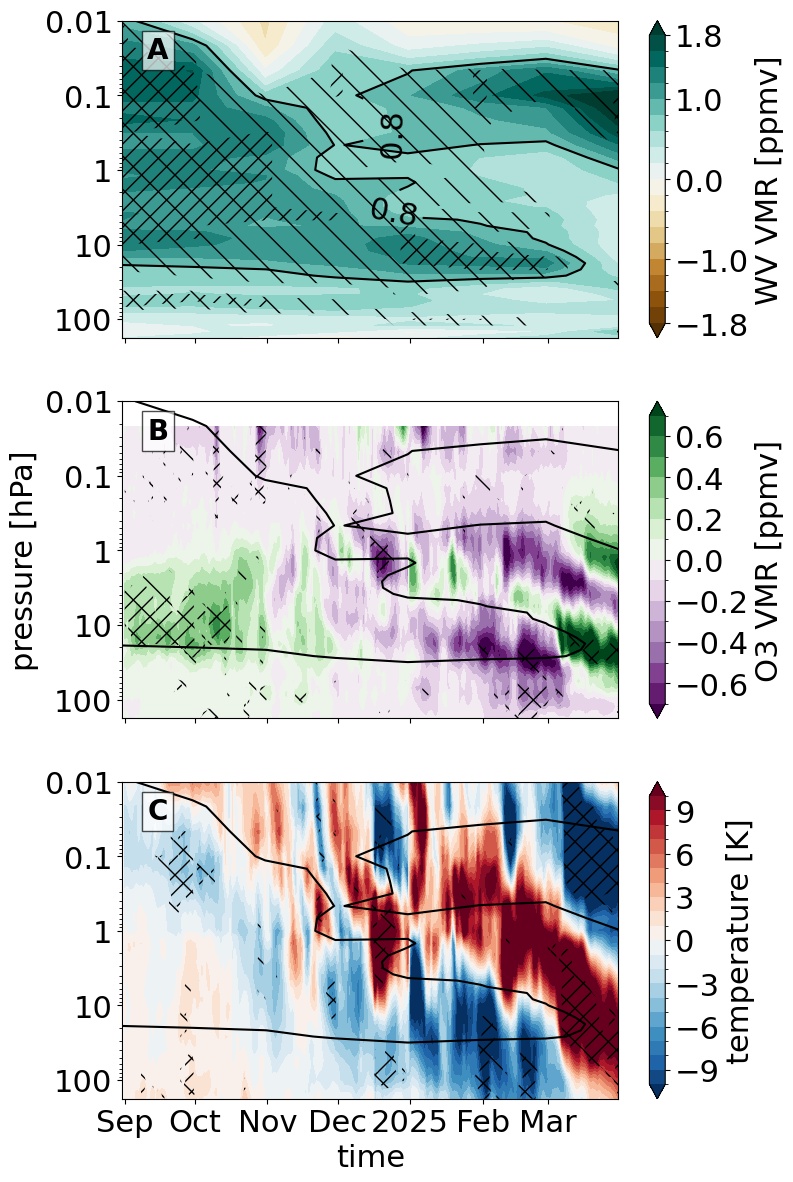

In [52]:
n_rows = 3
f, axes = plt.subplots(n_rows, 1, figsize=(8, 14), sharex =True)
weights = np.cos(np.deg2rad(ds.latitude_bins))
weights.name = "weights"
pres_start=200
pres_end = 0.01
s_year = 2024
e_year = 2025
s_month = 9
e_month = 3
time_start = f'{s_year}-{s_month:02d}'
time_end =  f'{e_year}-{e_month:02d}'
t_cmax = 10
t_cmax_step = 1

sel_var_ls = ['h2o','O3','temperature',]
cmap_ls = ['BrBG',"PRGn",'RdBu_r',]
long_name_ls = ['WV VMR', 'O3 VMR', 'temperature']


temp_dict = {}
for i, (sel_var, ax, cmap, long_name) in enumerate(zip(sel_var_ls,axes,cmap_ls, long_name_ls)):
   
    if sel_var == 'h2o':
        temp = anom_int_h2o[sel_var].sel(
            #latitude_bins = slice(60,None),
            time = slice(f'{s_year}-{s_month-1:02d}', time_end),
            pressure = slice(pres_start,pres_end),    
        )#.weighted(weights).mean('latitude_bins')
        temp = temp.interpolate_na(dim = 'time')
    else:
        temp = anom_int_to3[sel_var].sel(
            #latitude_bins = slice(60,None),
            time = slice(time_start, time_end),
            pressure = slice(pres_start,pres_end),    
        )#.weighted(weights).mean('latitude_bins')

    temp.attrs['long_name'] = long_name
    temp_dict[sel_var] = temp

    if sel_var == 'O3':
        p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = np.arange(-0.7,0.8,0.1),
            ax = ax, 
        )
        p_local_int[sel_var].sel(
            time = slice(time_start, time_end),
        ).plot.contourf(
            x = 'time', ax = ax, yincrease = False, 
            levels=[0, 0.05],
            hatches=["//", None],
            colors="none",
            add_colorbar=False,    
        )
        p_local_int[sel_var].sel(
            time = slice(time_start, time_end),
        ).plot.contourf(
            x = 'time', ax = ax, yincrease = False, 
            levels=[0, 0.1],
            hatches=["\\", None],
            colors="none",
            add_colorbar=False, 
        )
    elif sel_var == 'h2o':
        p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = np.arange(-1.8,2,0.2),
            ax = ax, cbar_kwargs = dict(ticks = [-1.8,-1,0,1,1.8])
        )
        p_local_int_h2o[sel_var].plot.contourf(
            x = 'time', ax = ax, yincrease = False, 
            levels=[0, 0.05],
            hatches=["//", None],
            colors="none",
            add_colorbar=False,    
        )
        p_local_int_h2o[sel_var].plot.contourf(
            x = 'time', ax = ax, yincrease = False, 
            levels=[0, 0.1],
            hatches=["\\", None],
            colors="none",
            add_colorbar=False,    
        )

        
    else:
        p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = np.arange(-t_cmax,t_cmax+t_cmax_step,t_cmax_step),#21,
            center = 0,
            ax = ax
        )
        p_local_int[sel_var].sel(
            time = slice(time_start, time_end),
        ).plot.contourf(
            x = 'time', ax = ax, yincrease = False, 
            levels=[0, 0.05],
            hatches=["//", None],
            colors="none",
            add_colorbar=False,    
        )
        p_local_int[sel_var].sel(
            time = slice(time_start, time_end),
        ).plot.contourf(
            x = 'time', ax = ax, yincrease = False, 
            levels=[0, 0.1],
            hatches=["\\", None],
            colors="none",
            add_colorbar=False, 
        )

        
    print(sel_var, p.colorbar.vmax)
    if sel_var in ['h2o','temperature','O3']:
        CS = temp_dict['h2o'].plot.contour(
            x = 'time', 
            yincrease = False, add_colorbar = False, 
            levels = [0.8],
            colors = ('k'),
            ax = ax
        )
    if sel_var in ['h2o']:
        ax.clabel(CS)
    
    ax.set_yscale('log')
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)
    
    if i != n_rows-1:
        ax.set_xlabel('')

    if i != 1:
        ax.set_ylabel('')

    label = ascii_uppercase[i]
    ax.text(
            0.05,
            0.95,
            label,
            transform=ax.transAxes,
            fontsize=20,
            fontweight="bold",
            va="top",
            bbox={"alpha": 0.7, "facecolor": "white"},
        )


outfile = f"TE+WV+O3_time-evolution_{time_start}-{time_end}_MLS{mls_suffix}_anom-int_significance.pdf"
print(outfile)
plt.savefig(outfile, bbox_inches="tight")

In [53]:
client = run_client()
client.exists(f"HT_analysis/figs/strengthening/{outfile}")

True

In [54]:
client.upload_file(outfile, f"HT_analysis/figs/strengthening/{outfile}", overwrite=True)

## 2025-2026

In [55]:
anom_int_to3 = (
    anom_int[["temperature", "O3"]].chunk({"time": -1})#.interpolate_na("time")
)
p_local_int = pvals_vs_reference_monthly(
    anom_int_to3,
    target_winter=2026,  # Oct 2024 - Mar 2025
    ref_winters=None,
    center_zero=True,
).load()
p_local_int

<xarray.Dataset> Size: 146kB
Dimensions:      (time: 243, pressure: 37)
Coordinates:
  * time         (time) datetime64[ns] 2kB 2025-08-01 2025-08-02 ... 2026-03-31
  * pressure     (pressure) float32 148B 177.8 146.8 121.2 ... 0.02154 0.01
Data variables:
    temperature  (time, pressure) float64 72kB 0.9569 0.7935 ... 0.3629 0.1838
    O3           (time, pressure) float64 72kB 0.08012 0.09707 ... 0.3899 nan
Attributes:
    title:    Aura MLS v6.01 Level-2 data product
    history:  Postprocessed by WEGC; screened using MLS precision estimates a...

In [56]:
anom_int_h2o = anom_int[['h2o']].chunk({'time':-1}).resample(time = '1M').mean().interpolate_na('time')
p_local_int_h2o = pvals_vs_reference_monthly(
    anom_int_h2o,
    target_winter=2026,  # Oct 2024 - Mar 2025
    ref_winters=None,
    center_zero=True,
).load()
p_local_int_h2o

<xarray.Dataset> Size: 3kB
Dimensions:   (time: 8, pressure: 37)
Coordinates:
  * time      (time) datetime64[ns] 64B 2025-08-31 2025-09-30 ... 2026-03-31
  * pressure  (pressure) float32 148B 177.8 146.8 121.2 ... 0.04642 0.02154 0.01
Data variables:
    h2o       (time, pressure) float64 2kB 0.8182 0.04545 ... 0.2727 0.2273
Attributes:
    title:    Aura MLS v6.01 Level-2 data product
    history:  Postprocessed by WEGC; screened using MLS precision estimates a...

h2o 1.7999999999999992
O3 0.6999999999999997
temperature 10.0
TE+WV+O3_time-evolution_2025-09-2026-03_MLSv6_anom-int_significance.pdf


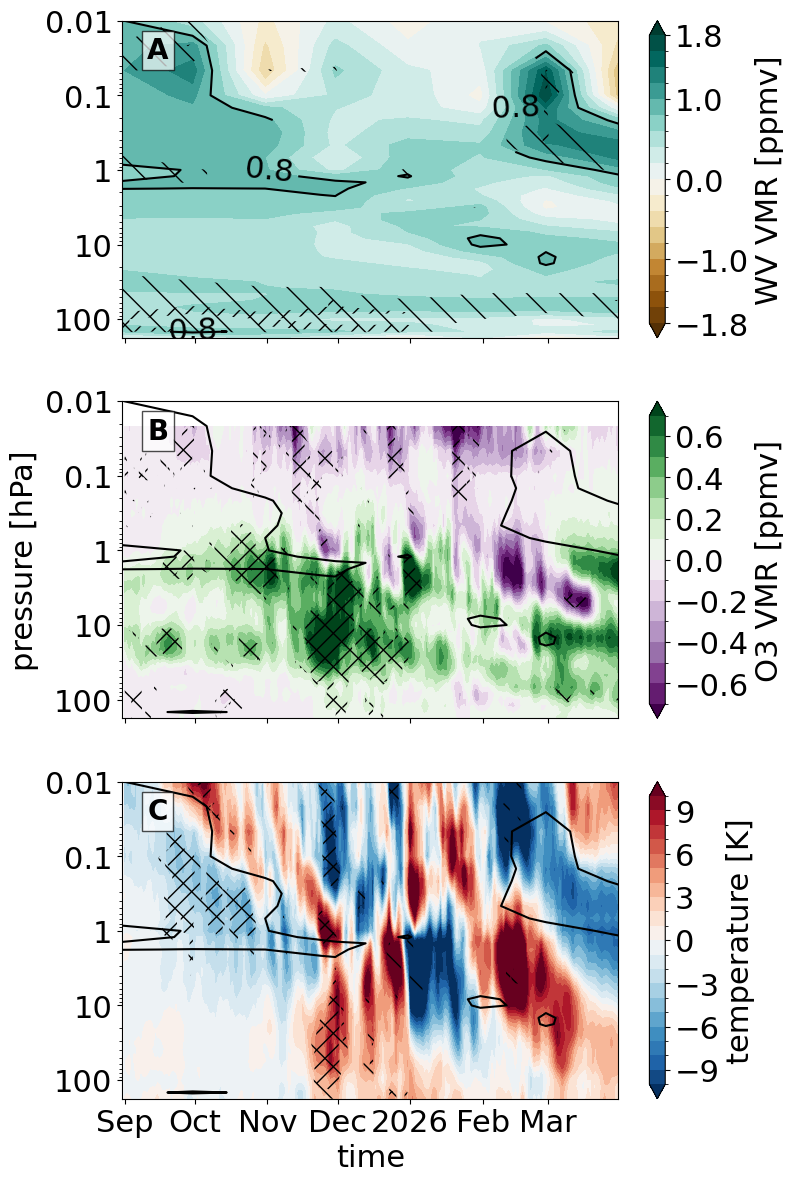

In [57]:
n_rows = 3
f, axes = plt.subplots(n_rows, 1, figsize=(8, 14), sharex =True)
weights = np.cos(np.deg2rad(ds.latitude_bins))
weights.name = "weights"
pres_start=200
pres_end = 0.01
s_year = 2025
e_year = 2026
s_month = 9
e_month = 3
time_start = f'{s_year}-{s_month:02d}'
time_end =  f'{e_year}-{e_month:02d}'
t_cmax = 10
t_cmax_step = 1

sel_var_ls = ['h2o','O3','temperature',]
cmap_ls = ['BrBG',"PRGn",'RdBu_r',]
long_name_ls = ['WV VMR', 'O3 VMR', 'temperature']


temp_dict = {}
for i, (sel_var, ax, cmap, long_name) in enumerate(zip(sel_var_ls,axes,cmap_ls, long_name_ls)):
   
    if sel_var == 'h2o':
        temp = anom_int_h2o[sel_var].sel(
            #latitude_bins = slice(60,None),
            time = slice(f'{s_year}-{s_month-1:02d}', time_end),
            pressure = slice(pres_start,pres_end),    
        )#.weighted(weights).mean('latitude_bins')
        temp = temp.interpolate_na(dim = 'time')
    else:
        temp = anom_int_to3[sel_var].sel(
            #latitude_bins = slice(60,None),
            time = slice(time_start, time_end),
            pressure = slice(pres_start,pres_end),    
        )#.weighted(weights).mean('latitude_bins')

    temp.attrs['long_name'] = long_name
    temp_dict[sel_var] = temp

    if sel_var == 'O3':
        p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = np.arange(-.7,.8,0.1),
            ax = ax, 
        )
        p_local_int[sel_var].sel(
            time = slice(time_start, time_end),
        ).plot.contourf(
            x = 'time', ax = ax, yincrease = False, 
            levels=[0, 0.05],
            hatches=["//", None],
            colors="none",
            add_colorbar=False,    
        )
        p_local_int[sel_var].sel(
            time = slice(time_start, time_end),
        ).plot.contourf(
            x = 'time', ax = ax, yincrease = False, 
            levels=[0, 0.1],
            hatches=["\\", None],
            colors="none",
            add_colorbar=False, 
        )
    elif sel_var == 'h2o':
        p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = np.arange(-1.8,2,0.2),
            ax = ax, cbar_kwargs = dict(ticks = [-1.8,-1,0,1,1.8])
        )
        p_local_int_h2o[sel_var].plot.contourf(
            x = 'time', ax = ax, yincrease = False, 
            levels=[0, 0.05],
            hatches=["//", None],
            colors="none",
            add_colorbar=False,    
        )
        p_local_int_h2o[sel_var].plot.contourf(
            x = 'time', ax = ax, yincrease = False, 
            levels=[0, 0.1],
            hatches=["\\", None],
            colors="none",
            add_colorbar=False,    
        )

        
    else:
        p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = np.arange(-t_cmax,t_cmax+t_cmax_step,t_cmax_step),#21,
            center = 0,
            ax = ax
        )
        p_local_int[sel_var].sel(
            time = slice(time_start, time_end),
        ).plot.contourf(
            x = 'time', ax = ax, yincrease = False, 
            levels=[0, 0.05],
            hatches=["//", None],
            colors="none",
            add_colorbar=False,    
        )
        p_local_int[sel_var].sel(
            time = slice(time_start, time_end),
        ).plot.contourf(
            x = 'time', ax = ax, yincrease = False, 
            levels=[0, 0.1],
            hatches=["\\", None],
            colors="none",
            add_colorbar=False, 
        )

        
    print(sel_var, p.colorbar.vmax)
    if sel_var in ['h2o','temperature','O3']:
        CS = temp_dict['h2o'].plot.contour(
            x = 'time', 
            yincrease = False, add_colorbar = False, 
            levels = [0.8],
            colors = ('k'),
            ax = ax
        )
    if sel_var in ['h2o']:
        ax.clabel(CS)
    
    ax.set_yscale('log')
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)
    
    if i != n_rows-1:
        ax.set_xlabel('')

    if i != 1:
        ax.set_ylabel('')

    label = ascii_uppercase[i]
    ax.text(
            0.05,
            0.95,
            label,
            transform=ax.transAxes,
            fontsize=20,
            fontweight="bold",
            va="top",
            bbox={"alpha": 0.7, "facecolor": "white"},
        )


outfile = f"TE+WV+O3_time-evolution_{time_start}-{time_end}_MLS{mls_suffix}_anom-int_significance.pdf"
print(outfile)
plt.savefig(outfile, bbox_inches="tight")

In [58]:
client = run_client()
client.exists(f"HT_analysis/figs/strengthening/{outfile}")

True

In [59]:
client.upload_file(outfile, f"HT_analysis/figs/strengthening/{outfile}", overwrite=True)

## 2021-2022

In [60]:
anom_int_to3 = (
    anom_int[["temperature", "O3"]].chunk({"time": -1})#.interpolate_na("time")
)
p_local_int = pvals_vs_reference_monthly(
    anom_int_to3,
    target_winter=2022,  # Oct 2024 - Mar 2025
    ref_winters=None,
    center_zero=True,
).load()
p_local_int

<xarray.Dataset> Size: 146kB
Dimensions:      (time: 243, pressure: 37)
Coordinates:
  * time         (time) datetime64[ns] 2kB 2021-08-01 2021-08-02 ... 2022-03-31
  * pressure     (pressure) float32 148B 177.8 146.8 121.2 ... 0.02154 0.01
Data variables:
    temperature  (time, pressure) float64 72kB 0.5917 0.5809 ... 0.9081 0.5325
    O3           (time, pressure) float64 72kB 0.4176 0.3482 ... 0.7765 nan
Attributes:
    title:    Aura MLS v6.01 Level-2 data product
    history:  Postprocessed by WEGC; screened using MLS precision estimates a...

In [61]:
anom_int_h2o = anom_int[['h2o']].chunk({'time':-1}).resample(time = '1M').mean().interpolate_na('time')
p_local_int_h2o = pvals_vs_reference_monthly(
    anom_int_h2o,
    target_winter=2022,  # Oct 2024 - Mar 2025
    ref_winters=None,
    center_zero=True,
).load()
p_local_int_h2o

<xarray.Dataset> Size: 3kB
Dimensions:   (time: 8, pressure: 37)
Coordinates:
  * time      (time) datetime64[ns] 64B 2021-08-31 2021-09-30 ... 2022-03-31
  * pressure  (pressure) float32 148B 177.8 146.8 121.2 ... 0.04642 0.02154 0.01
Data variables:
    h2o       (time, pressure) float64 2kB 0.3182 0.1364 1.0 ... 0.9091 0.8636
Attributes:
    title:    Aura MLS v6.01 Level-2 data product
    history:  Postprocessed by WEGC; screened using MLS precision estimates a...

h2o 1.7999999999999992
O3 0.6999999999999997
temperature 10.0
TE+WV+O3_time-evolution_2021-09-2022-03_MLSv6_anom-int_significance.pdf


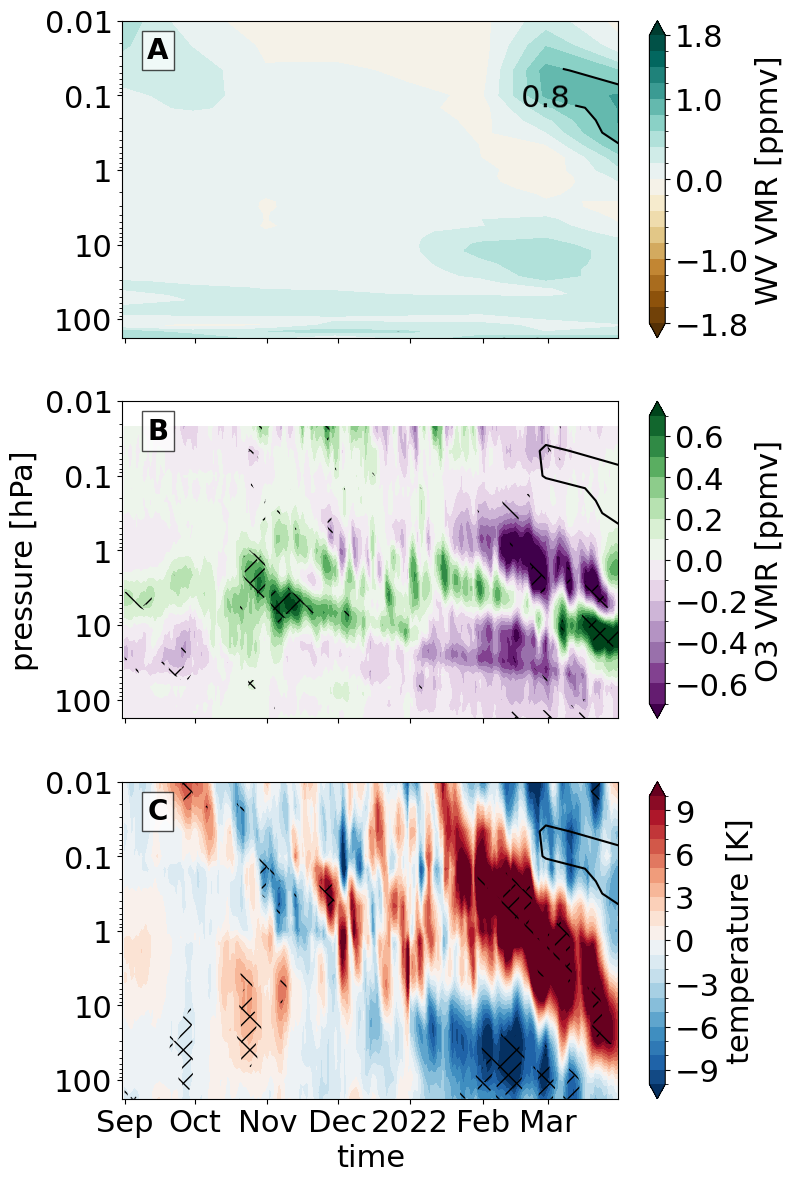

In [62]:
n_rows = 3
f, axes = plt.subplots(n_rows, 1, figsize=(8, 14), sharex =True)
weights = np.cos(np.deg2rad(ds.latitude_bins))
weights.name = "weights"
pres_start=200
pres_end = 0.01
s_year = 2021
e_year = 2022
s_month = 9
e_month = 3
time_start = f'{s_year}-{s_month:02d}'
time_end =  f'{e_year}-{e_month:02d}'
t_cmax = 10
t_cmax_step = 1

sel_var_ls = ['h2o','O3','temperature',]
cmap_ls = ['BrBG',"PRGn",'RdBu_r',]
long_name_ls = ['WV VMR', 'O3 VMR', 'temperature']


temp_dict = {}
for i, (sel_var, ax, cmap, long_name) in enumerate(zip(sel_var_ls,axes,cmap_ls, long_name_ls)):
   
    if sel_var == 'h2o':
        temp = anom_int_h2o[sel_var].sel(
            #latitude_bins = slice(60,None),
            time = slice(f'{s_year}-{s_month-1:02d}', time_end),
            pressure = slice(pres_start,pres_end),    
        )#.weighted(weights).mean('latitude_bins')
        temp = temp.interpolate_na(dim = 'time')
    else:
        temp = anom_int_to3[sel_var].sel(
            #latitude_bins = slice(60,None),
            time = slice(time_start, time_end),
            pressure = slice(pres_start,pres_end),    
        )#.weighted(weights).mean('latitude_bins')

    temp.attrs['long_name'] = long_name
    temp_dict[sel_var] = temp

    if sel_var == 'O3':
        p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = np.arange(-.7,.8,0.1),
            ax = ax, 
        )
        p_local_int[sel_var].sel(
            time = slice(time_start, time_end),
        ).plot.contourf(
            x = 'time', ax = ax, yincrease = False, 
            levels=[0, 0.05],
            hatches=["//", None],
            colors="none",
            add_colorbar=False,    
        )
        p_local_int[sel_var].sel(
            time = slice(time_start, time_end),
        ).plot.contourf(
            x = 'time', ax = ax, yincrease = False, 
            levels=[0, 0.1],
            hatches=["\\", None],
            colors="none",
            add_colorbar=False, 
        )
    elif sel_var == 'h2o':
        p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = np.arange(-1.8,2,0.2),
            ax = ax, cbar_kwargs = dict(ticks = [-1.8,-1,0,1,1.8])
        )
        p_local_int_h2o[sel_var].plot.contourf(
            x = 'time', ax = ax, yincrease = False, 
            levels=[0, 0.05],
            hatches=["//", None],
            colors="none",
            add_colorbar=False,    
        )
        p_local_int_h2o[sel_var].plot.contourf(
            x = 'time', ax = ax, yincrease = False, 
            levels=[0, 0.1],
            hatches=["\\", None],
            colors="none",
            add_colorbar=False,    
        )

        
    else:
        p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = np.arange(-t_cmax,t_cmax+t_cmax_step,t_cmax_step),#21,
            center = 0,
            ax = ax
        )
        p_local_int[sel_var].sel(
            time = slice(time_start, time_end),
        ).plot.contourf(
            x = 'time', ax = ax, yincrease = False, 
            levels=[0, 0.05],
            hatches=["//", None],
            colors="none",
            add_colorbar=False,    
        )
        p_local_int[sel_var].sel(
            time = slice(time_start, time_end),
        ).plot.contourf(
            x = 'time', ax = ax, yincrease = False, 
            levels=[0, 0.1],
            hatches=["\\", None],
            colors="none",
            add_colorbar=False, 
        )

        
    print(sel_var, p.colorbar.vmax)
    if sel_var in ['h2o','temperature','O3']:
        CS = temp_dict['h2o'].plot.contour(
            x = 'time', 
            yincrease = False, add_colorbar = False, 
            levels = [0.8],
            colors = ('k'),
            ax = ax
        )
    if sel_var in ['h2o']:
        ax.clabel(CS)
    
    ax.set_yscale('log')
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)
    
    if i != n_rows-1:
        ax.set_xlabel('')

    if i != 1:
        ax.set_ylabel('')

    label = ascii_uppercase[i]
    ax.text(
            0.05,
            0.95,
            label,
            transform=ax.transAxes,
            fontsize=20,
            fontweight="bold",
            va="top",
            bbox={"alpha": 0.7, "facecolor": "white"},
        )


outfile = f"TE+WV+O3_time-evolution_{time_start}-{time_end}_MLS{mls_suffix}_anom-int_significance.pdf"
print(outfile)
plt.savefig(outfile, bbox_inches="tight")

In [63]:
client = run_client()
client.exists(f"HT_analysis/figs/strengthening/{outfile}")

True

In [64]:
client.upload_file(outfile, f"HT_analysis/figs/strengthening/{outfile}", overwrite=True)

## 2015-2016

In [65]:
anom_int_to3 = (
    anom_int[["temperature", "O3"]].chunk({"time": -1})#.interpolate_na("time")
)
p_local_int = pvals_vs_reference_monthly(
    anom_int_to3,
    target_winter=2016,  # Oct 2024 - Mar 2025
    ref_winters=None,
    center_zero=True,
).load()
p_local_int

<xarray.Dataset> Size: 147kB
Dimensions:      (time: 244, pressure: 37)
Coordinates:
  * time         (time) datetime64[ns] 2kB 2015-08-01 2015-08-02 ... 2016-03-31
  * pressure     (pressure) float32 148B 177.8 146.8 121.2 ... 0.02154 0.01
Data variables:
    temperature  (time, pressure) float64 72kB 0.2296 0.151 ... 0.8526 0.6799
    O3           (time, pressure) float64 72kB 0.7257 0.9245 ... 0.8558 nan
Attributes:
    title:    Aura MLS v6.01 Level-2 data product
    history:  Postprocessed by WEGC; screened using MLS precision estimates a...

In [66]:
anom_int_h2o = anom_int[['h2o']].chunk({'time':-1}).resample(time = '1M').mean().interpolate_na('time')
p_local_int_h2o = pvals_vs_reference_monthly(
    anom_int_h2o,
    target_winter=2016,  # Oct 2024 - Mar 2025
    ref_winters=None,
    center_zero=True,
).load()
p_local_int_h2o

<xarray.Dataset> Size: 3kB
Dimensions:   (time: 8, pressure: 37)
Coordinates:
  * time      (time) datetime64[ns] 64B 2015-08-31 2015-09-30 ... 2016-03-31
  * pressure  (pressure) float32 148B 177.8 146.8 121.2 ... 0.04642 0.02154 0.01
Data variables:
    h2o       (time, pressure) float64 2kB 0.5455 0.7727 ... 0.1818 0.1818
Attributes:
    title:    Aura MLS v6.01 Level-2 data product
    history:  Postprocessed by WEGC; screened using MLS precision estimates a...

h2o 1.7999999999999992
O3 0.6999999999999997
temperature 10.0
TE+WV+O3_time-evolution_2015-09-2016-03_MLSv6_anom-int_significance.pdf


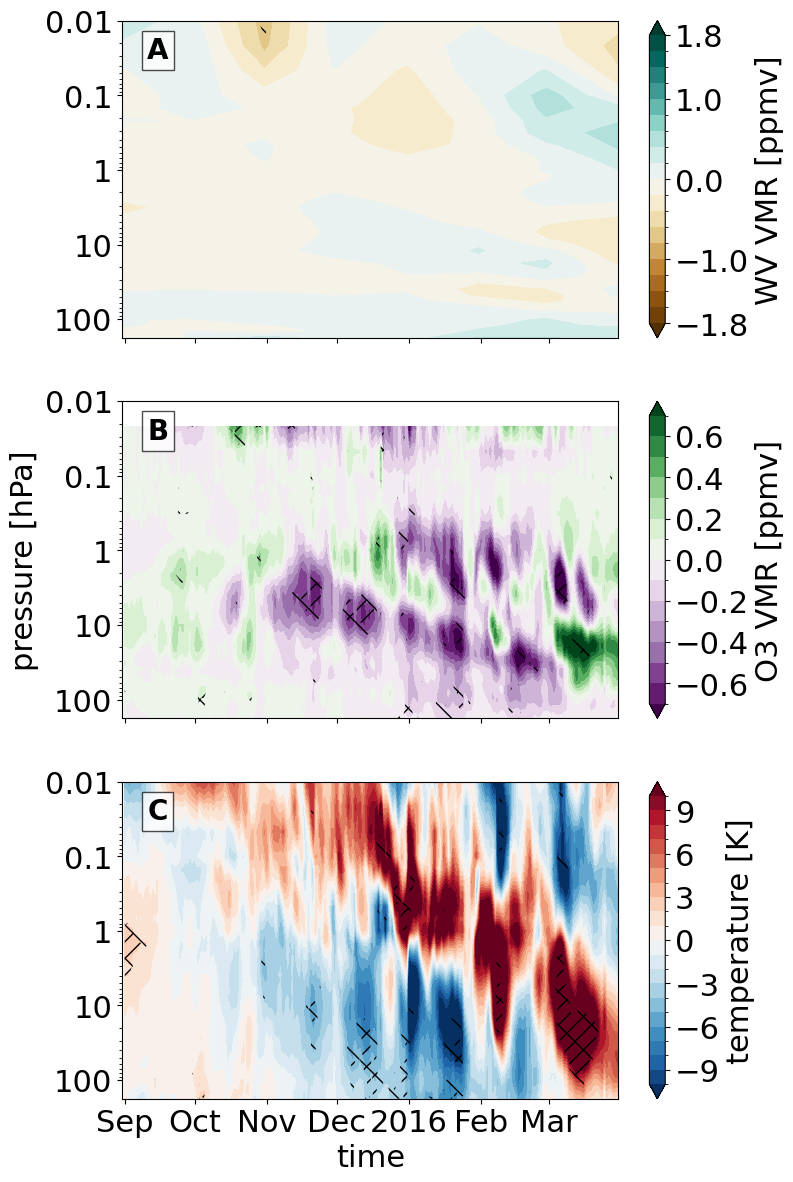

In [67]:
n_rows = 3
f, axes = plt.subplots(n_rows, 1, figsize=(8, 14), sharex =True)
weights = np.cos(np.deg2rad(ds.latitude_bins))
weights.name = "weights"
pres_start=200
pres_end = 0.01
s_year = 2015
e_year = 2016
s_month = 9
e_month = 3
time_start = f'{s_year}-{s_month:02d}'
time_end =  f'{e_year}-{e_month:02d}'
t_cmax = 10
t_cmax_step = 1

sel_var_ls = ['h2o','O3','temperature',]
cmap_ls = ['BrBG',"PRGn",'RdBu_r',]
long_name_ls = ['WV VMR', 'O3 VMR', 'temperature']


temp_dict = {}
for i, (sel_var, ax, cmap, long_name) in enumerate(zip(sel_var_ls,axes,cmap_ls, long_name_ls)):
   
    if sel_var == 'h2o':
        temp = anom_int_h2o[sel_var].sel(
            #latitude_bins = slice(60,None),
            time = slice(f'{s_year}-{s_month-1:02d}', time_end),
            pressure = slice(pres_start,pres_end),    
        )#.weighted(weights).mean('latitude_bins')
        temp = temp.interpolate_na(dim = 'time')
    else:
        temp = anom_int_to3[sel_var].sel(
            #latitude_bins = slice(60,None),
            time = slice(time_start, time_end),
            pressure = slice(pres_start,pres_end),    
        )#.weighted(weights).mean('latitude_bins')

    temp.attrs['long_name'] = long_name
    temp_dict[sel_var] = temp

    if sel_var == 'O3':
        p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = np.arange(-.7,.8,0.1),
            ax = ax, 
        )
        p_local_int[sel_var].sel(
            time = slice(time_start, time_end),
        ).plot.contourf(
            x = 'time', ax = ax, yincrease = False, 
            levels=[0, 0.05],
            hatches=["//", None],
            colors="none",
            add_colorbar=False,    
        )
        p_local_int[sel_var].sel(
            time = slice(time_start, time_end),
        ).plot.contourf(
            x = 'time', ax = ax, yincrease = False, 
            levels=[0, 0.1],
            hatches=["\\", None],
            colors="none",
            add_colorbar=False, 
        )
    elif sel_var == 'h2o':
        p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = np.arange(-1.8,2,0.2),
            ax = ax, cbar_kwargs = dict(ticks = [-1.8,-1,0,1,1.8])
        )
        p_local_int_h2o[sel_var].plot.contourf(
            x = 'time', ax = ax, yincrease = False, 
            levels=[0, 0.05],
            hatches=["//", None],
            colors="none",
            add_colorbar=False,    
        )
        p_local_int_h2o[sel_var].plot.contourf(
            x = 'time', ax = ax, yincrease = False, 
            levels=[0, 0.1],
            hatches=["\\", None],
            colors="none",
            add_colorbar=False,    
        )

        
    else:
        p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = np.arange(-t_cmax,t_cmax+t_cmax_step,t_cmax_step),#21,
            center = 0,
            ax = ax
        )
        p_local_int[sel_var].sel(
            time = slice(time_start, time_end),
        ).plot.contourf(
            x = 'time', ax = ax, yincrease = False, 
            levels=[0, 0.05],
            hatches=["//", None],
            colors="none",
            add_colorbar=False,    
        )
        p_local_int[sel_var].sel(
            time = slice(time_start, time_end),
        ).plot.contourf(
            x = 'time', ax = ax, yincrease = False, 
            levels=[0, 0.1],
            hatches=["\\", None],
            colors="none",
            add_colorbar=False, 
        )

        
    print(sel_var, p.colorbar.vmax)
    if sel_var in ['h2o','temperature','O3']:
        CS = temp_dict['h2o'].plot.contour(
            x = 'time', 
            yincrease = False, add_colorbar = False, 
            levels = [0.8],
            colors = ('k'),
            ax = ax
        )
    if sel_var in ['h2o']:
        ax.clabel(CS)
    
    ax.set_yscale('log')
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)
    
    if i != n_rows-1:
        ax.set_xlabel('')

    if i != 1:
        ax.set_ylabel('')

    label = ascii_uppercase[i]
    ax.text(
            0.05,
            0.95,
            label,
            transform=ax.transAxes,
            fontsize=20,
            fontweight="bold",
            va="top",
            bbox={"alpha": 0.7, "facecolor": "white"},
        )


outfile = f"TE+WV+O3_time-evolution_{time_start}-{time_end}_MLS{mls_suffix}_anom-int_significance.pdf"
print(outfile)
plt.savefig(outfile, bbox_inches="tight")

In [68]:
client = run_client()
client.exists(f"HT_analysis/figs/strengthening/{outfile}")

True

In [69]:
client.upload_file(outfile, f"HT_analysis/figs/strengthening/{outfile}", overwrite=True)